# Road Accident Severity Classification

## Project Overview

Road accidents are a significant global concern, impacting public health,
safety, and economic stability.

Understanding and analyzing road accident data is crucial for developing
effective strategies to reduce the frequency and severity of these incidents.

This project aims to leverage machine learning techniques to analyze road
accident data and predict accident severity based on various accident,
environmental, and road-related factors.
Necessity of the Project:
1. Public Safety: Road accidents cause numerous injuries and fatalities each year. By analyzing accident data, we can identify patterns and high-risk areas, leading to targeted interventions that enhance road safety and reduce the number of accidents.

2. Economic Impact: Accidents result in substantial economic costs, including medical expenses, property damage, and loss of productivity. Understanding the factors contributing to accidents can help in allocating resources more effectively and minimizing these financial burdens.

3. Policy Development: Effective road safety policies require a deep understanding of accident trends and contributing factors. This project provides valuable insights that can guide policymakers in designing evidence-based regulations and safety measures.

4. Infrastructure Planning: Identifying accident-prone areas can inform infrastructure improvements, such as better road design, signage, and traffic management systems. This proactive approach can prevent accidents before they occur.

Why We Should Consider This Project:
1. Data-Driven Insights: By analyzing comprehensive accident data, including variables such as location, time, weather conditions, and vehicle types, we can uncover critical patterns and correlations. This helps in understanding the root causes of accidents and identifying preventive measures.

2. Enhanced Safety Measures: Insights gained from the analysis can lead to the implementation of targeted safety measures, such as improved road signage, better lighting, and enhanced law enforcement in high-risk areas.

3. Community Awareness: The project can raise awareness about road safety among the public, encouraging safer driving practices and fostering a culture of responsibility on the roads.

4. Resource Optimization: By identifying high-risk areas and accident trends, resources such as emergency services and road maintenance can be allocated more efficiently, maximizing their impact.



Location of the Dataset
The dataset focuses on car accidents in the United Kingdom. This geographical focus allows for a detailed analysis of accident patterns specific to the UK's road networks and driving conditions.

This project provides a valuable resource for those aiming to make data-driven decisions in traffic safety and public health, with the potential to significantly reduce the frequency and severity of road traffic accidents.




In conclusion, the Road Accident Project is a vital initiative that aims to reduce road accidents and their associated impacts through data-driven insights. By understanding accident patterns and contributing factors, we can develop more effective safety strategies, enhance public awareness, and contribute to the overall well-being of our communities.

In [1]:
#!pip install category_encoders

In [2]:
#import sys
#!{sys.executable} -m pip install xgboost

## importing libararies


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, NuSVC, OneClassSVM
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from category_encoders import TargetEncoder
from sklearn.feature_selection import SelectKBest, chi2
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.combine import SMOTEENN
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Loading the Data

In [4]:
df = pd.read_csv('Road Accident Data.csv')
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [5]:
df.shape

(307973, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  str    
 1   Accident Date               307973 non-null  str    
 2   Day_of_Week                 307973 non-null  str    
 3   Junction_Control            307973 non-null  str    
 4   Junction_Detail             307973 non-null  str    
 5   Accident_Severity           307973 non-null  str    
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  str    
 8   Local_Authority_(District)  307973 non-null  str    
 9   Carriageway_Hazards         5424 non-null    str    
 10  Longitude                   307973 non-null  float64
 11  Number_of_Casualties        307973 non-null  int64  
 12  Number_of_Vehicles          307973 non-null  int64  
 13  Police_Force             

In [7]:
df.describe()

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,52.487005,-1.368884,1.356882,1.829063,38.866037
std,1.339011,1.356092,0.815857,0.710477,14.032933
min,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,53.415517,-0.206810,1.000000,2.000000,50.000000
max,60.598055,1.759398,48.000000,32.000000,70.000000


In [8]:
df.describe(include ='object')

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Police_Force,Road_Surface_Conditions,Road_Type,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
count,307973,307973,307973,307973,307973,307973,307973,307973,5424,307973,307656,306439,307956,307973,301916,307973
unique,197644,730,7,7,9,4,5,422,5,51,5,5,1439,2,8,15
top,2.01E+12,11/13/2021,Friday,Give way or uncontrolled,Not at junction or within 20 metres,Slight,Daylight,Birmingham,Other object on road,Metropolitan Police,Dry,Single carriageway,17:00,Urban,Fine no high winds,Car
freq,110304,692,50529,150045,123094,263280,227286,6165,2243,46789,208967,230612,2933,198532,244496,239794


## Data Preperation

In [9]:
(df.isnull().sum() / df.shape[0]*100).sort_values(ascending=False)

Carriageway_Hazards           98.238807
Weather_Conditions             1.966731
Road_Type                      0.498096
Road_Surface_Conditions        0.102931
Time                           0.005520
Junction_Detail                0.000000
Junction_Control               0.000000
Day_of_Week                    0.000000
Accident Date                  0.000000
Accident_Index                 0.000000
Accident_Severity              0.000000
Light_Conditions               0.000000
Latitude                       0.000000
Number_of_Vehicles             0.000000
Number_of_Casualties           0.000000
Longitude                      0.000000
Local_Authority_(District)     0.000000
Speed_limit                    0.000000
Police_Force                   0.000000
Urban_or_Rural_Area            0.000000
Vehicle_Type                   0.000000
dtype: float64

In [10]:
df.drop('Accident_Index', axis =1, inplace =True)
df.drop('Carriageway_Hazards', axis =1, inplace =True) # More Than 98% of its values are nulls

In [11]:
df['Accident_Severity'].unique()

<StringArray>
['Serious', 'Slight', 'Fetal', 'Fatal']
Length: 4, dtype: str

In [12]:
df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')

In [13]:
df.isnull().sum()

Accident Date                    0
Day_of_Week                      0
Junction_Control                 0
Junction_Detail                  0
Accident_Severity                0
Latitude                         0
Light_Conditions                 0
Local_Authority_(District)       0
Longitude                        0
Number_of_Casualties             0
Number_of_Vehicles               0
Police_Force                     0
Road_Surface_Conditions        317
Road_Type                     1534
Speed_limit                      0
Time                            17
Urban_or_Rural_Area              0
Weather_Conditions            6057
Vehicle_Type                     0
dtype: int64

In [14]:
df['Time'] = pd.to_datetime(df['Time'])

In [15]:
# Creating a copy of the dataframe to avoid modifying the original data
df_cleaned = df.copy()

# List of categorical columns to impute with the mode
categorical_columns = [
    'Junction_Control', 'Road_Surface_Conditions', 'Road_Type',
    'Weather_Conditions'
]

# Imputing the categorical features with the mode (most frequent value)
for col in categorical_columns:
    mode_value = df_cleaned[col].mode()[0]
    df_cleaned[col] = df_cleaned[col].fillna(mode_value)

# Imputing 'Time' with the mean
mean_value = df_cleaned['Time'].mean()
df_cleaned['Time'] = df_cleaned['Time'].fillna(mean_value)

# Verifying that missing values have been handled
print(df_cleaned.isnull().sum())

Accident Date                 0
Day_of_Week                   0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64


In [16]:
# ==============================
# Category Mapping Dictionaries
# ==============================

light_conditions_map = {
    "Daylight": "Daylight",
    "Darkness - lights lit": "Dark_Lit",
    "Darkness - no lighting": "Dark_No_Light",
    "Darkness - lighting unknown": "Dark_Unknown",
    "Darkness - lights unlit": "Dark_Unlit"
}

road_surface_map = {
    "Dry": "Dry",
    "Wet or damp": "Wet",
    "Snow": "Snow",
    "Frost or ice": "Ice",
    "Flood over 3cm. deep": "Flood"
}

weather_conditions_map = {
    "Fine no high winds": "Clear",
    "Raining no high winds": "Rain",
    "Snowing no high winds": "Snow",
    "Fine + high winds": "Windy_Clear",
    "Raining + high winds": "Windy_Rain",
    "Snowing + high winds": "Windy_Snow",
    "Fog or mist": "Fog",
    "Other": "Other"
}

junction_control_map = {
    "Give way or uncontrolled": "Uncontrolled",
    "Auto traffic signal": "Traffic_Signal",
    "Auto traffic sigl": "Traffic_Signal",
    "Stop sign": "Stop_Sign",
    "Authorised person": "Authorised_Person",
    "Not at junction or within 20 metres": "Not_at_Junction"
}

junction_detail_map = {
    "Not at junction or within 20 metres": "No_Junction",
    "Roundabout": "Roundabout",
    "Mini-roundabout": "Mini_Roundabout",
    "T or staggered junction": "Staggered",
    "Slip road": "Slip_Road",
    "Crossroads": "Crossroads",
    "More than 4 arms (not roundabout)": "Complex",
    "Private drive or entrance": "Private_Entrance",
    "Other junction": "Other"
}

vehicle_type_map = {
    "Car": "Car",
    "Van / Goods 3.5 tonnes mgw or under": "Light_Van",
    "Motorcycle over 500cc": "Motorcycle",
    "Bus or coach (17 or more pass seats)": "Bus_Coach",
    "Motorcycle 125cc and under": "Motorcycle",
    "Goods 7.5 tonnes mgw and over": "HeavyGoods",
    "Taxi/Private hire car": "Taxi_Private",
    "Motorcycle 50cc and under": "Motorcycle",
    "Motorcycle over 125cc and up to 500cc": "Motorcycle",
    "Other vehicle": "Other_Vehicle",
    "Goods over 3.5t. and under 7.5t": "MediumGoods",
    "Minibus (8 - 16 passenger seats)": "Minibus",
    "Agricultural vehicle": "Agricultural_Vehicle",
    "Pedal cycle": "Bicycle",
    "Ridden horse": "Horse"
}

road_type_map = {
    "Single carriageway": "Single",
    "Dual carriageway": "Dual",
    "Roundabout": "Roundabout",
    "One way street": "One_Way",
    "Slip road": "Slip_Road"
}

police_force_map = {
    "Metropolitan Police": "Met_Police",
    "City of London": "City_of_London",
    "Cumbria": "Cumbria",
    "Lancashire": "Lancashire",
    "Merseyside": "Merseyside",
    "Greater Manchester": "Greater_Manchester",
    "Cheshire": "Cheshire",
    "Northumbria": "Northumbria",
    "Durham": "Durham",
    "North Yorkshire": "North_Yorkshire",
    "West Yorkshire": "West_Yorkshire",
    "South Yorkshire": "South_Yorkshire",
    "Humberside": "Humberside",
    "Cleveland": "Cleveland",
    "West Midlands": "West_Midlands",
    "Staffordshire": "Staffordshire",
    "West Mercia": "West_Mercia",
    "Warwickshire": "Warwickshire",
    "Derbyshire": "Derbyshire",
    "Nottinghamshire": "Nottinghamshire",
    "Lincolnshire": "Lincolnshire",
    "Leicestershire": "Leicestershire",
    "Northamptonshire": "Northamptonshire",
    "Cambridgeshire": "Cambridgeshire",
    "Norfolk": "Norfolk",
    "Suffolk": "Suffolk",
    "Bedfordshire": "Bedfordshire",
    "Hertfordshire": "Hertfordshire",
    "Essex": "Essex",
    "Thames Valley": "Thames_Valley",
    "Hampshire": "Hampshire",
    "Surrey": "Surrey",
    "Kent": "Kent",
    "Sussex": "Sussex",
    "Devon and Cornwall": "Devon_Cornwall",
    "Avon and Somerset": "Avon_Somerset",
    "Gloucestershire": "Gloucestershire",
    "Wiltshire": "Wiltshire",
    "Dorset": "Dorset",
    "North Wales": "North_Wales",
    "Gwent": "Gwent",
    "South Wales": "South_Wales",
    "Dyfed-Powys": "Dyfed_Powys",
    "Northern": "Northern",
    "Grampian": "Grampian",
    "Tayside": "Tayside",
    "Fife": "Fife",
    "Lothian and Borders": "Lothian_Borders",
    "Central": "Central",
    "Strathclyde": "Strathclyde",
    "Dumfries and Galloway": "Dumfries_Galloway"
}


# ==============================
# Apply Mapping
# ==============================

df['Light_Conditions'] = df['Light_Conditions'].replace(light_conditions_map)

df['Road_Surface_Conditions'] = df['Road_Surface_Conditions'].replace(road_surface_map)

df['Weather_Conditions'] = df['Weather_Conditions'].replace(weather_conditions_map)

df['Junction_Control'] = df['Junction_Control'].replace(junction_control_map)

df['Junction_Detail'] = df['Junction_Detail'].replace(junction_detail_map)

df['Vehicle_Type'] = df['Vehicle_Type'].replace(vehicle_type_map)

df['Police_Force'] = df['Police_Force'].replace(police_force_map)

df['Road_Type'] = df['Road_Type'].replace(road_type_map)

In [17]:
df_cleaned.duplicated().sum()

np.int64(5)

In [18]:
df_cleaned.drop_duplicates(inplace=True)

In [19]:
df_cleaned['Accident Date'] = pd.to_datetime(df['Accident Date'])
df_cleaned['Year'] = df_cleaned['Accident Date'].dt.year
df_cleaned['Month'] = df_cleaned['Accident Date'].dt.month
df_cleaned['Day'] = df_cleaned['Accident Date'].dt.day
df_cleaned['Hour'] = pd.to_datetime(df_cleaned['Time'], errors='coerce').dt.hour

In [20]:
df_cleaned['Time'] = pd.to_datetime(df_cleaned['Time'], format='%H:%M').dt.time
df_cleaned.sample(n=10)

,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,...,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Year,Month,Day,Hour
42796,2021-02-11,Wednesday,Give way or uncontrolled,T or staggered junction,Slight,54.902298,Darkness - lights lit,Sunderland,-1.399411,1,...,Single carriageway,30,01:33:00,Urban,Fine no high winds,Taxi/Private hire car,2021,2,11,1
147947,2021-02-13,Friday,Data missing or out of range,Not at junction or within 20 metres,Slight,51.648672,Daylight,Swansea,-3.924538,1,...,Single carriageway,30,13:38:00,Urban,Other,Car,2021,2,13,13
185556,2022-10-31,Sunday,Give way or uncontrolled,Private drive or entrance,Slight,51.608118,Daylight,Waltham Forest,-0.032197,3,...,Single carriageway,30,12:15:00,Urban,Fine no high winds,Goods 7.5 tonnes mgw and over,2022,10,31,12
174976,2022-06-19,Saturday,Give way or uncontrolled,Crossroads,Slight,51.475137,Daylight,Lewisham,-0.038934,7,...,Single carriageway,30,13:40:00,Urban,Fine no high winds,Car,2022,6,19,13
218435,2022-07-27,Tuesday,Give way or uncontrolled,T or staggered junction,Slight,53.544797,Daylight,Doncaster,-1.098097,2,...,Dual carriageway,30,16:15:00,Urban,Fine no high winds,Car,2022,7,27,16
240313,2022-03-28,Sunday,Data missing or out of range,Not at junction or within 20 metres,Serious,52.926568,Darkness - lights lit,Derby,-1.463853,2,...,Dual carriageway,60,22:01:00,Rural,Fine no high winds,Car,2022,3,28,22
258793,2022-09-23,Thursday,Give way or uncontrolled,Roundabout,Slight,51.794036,Darkness - lights lit,East Hertfordshire,-0.078205,1,...,Single carriageway,30,20:33:00,Urban,Other,Van / Goods 3.5 tonnes mgw or under,2022,9,23,20
255380,2022-04-01,Thursday,Give way or uncontrolled,T or staggered junction,Slight,52.334828,Daylight,Forest Heath,0.531581,2,...,Dual carriageway,50,18:45:00,Rural,Raining no high winds,Car,2022,4,1,18
71136,2021-03-21,Saturday,Data missing or out of range,Not at junction or within 20 metres,Slight,52.478825,Daylight,Dudley,-2.022200,1,...,Dual carriageway,70,12:58:00,Urban,Fine no high winds,Car,2021,3,21,12
206426,2022-06-09,Wednesday,Give way or uncontrolled,Roundabout,Slight,54.905201,Daylight,Sunderland,-1.527879,1,...,Single carriageway,30,16:05:00,Urban,Raining no high winds,Car,2022,6,9,16


In [21]:
df_cleaned['Slight'] = (df_cleaned['Accident_Severity'] == 'Slight').astype(int)

In [22]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 307968 entries, 0 to 307972
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Accident Date               307968 non-null  datetime64[us]
 1   Day_of_Week                 307968 non-null  str           
 2   Junction_Control            307968 non-null  str           
 3   Junction_Detail             307968 non-null  str           
 4   Accident_Severity           307968 non-null  str           
 5   Latitude                    307968 non-null  float64       
 6   Light_Conditions            307968 non-null  str           
 7   Local_Authority_(District)  307968 non-null  str           
 8   Longitude                   307968 non-null  float64       
 9   Number_of_Casualties        307968 non-null  int64         
 10  Number_of_Vehicles          307968 non-null  int64         
 11  Police_Force                307968 non-null  str       

# EDA


Accident Severity


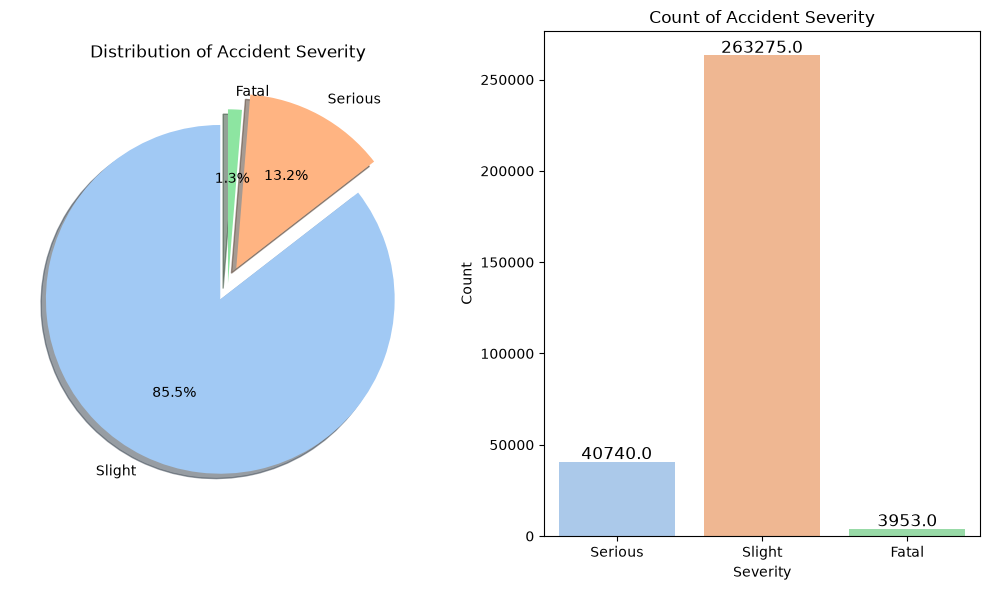

In [23]:
target_column = 'Accident_Severity'

# Creating subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

# Pie Chart
sizes = df_cleaned[target_column].value_counts()
labels = sizes.index
ax[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=sns.color_palette('pastel'),
          startangle=90, explode=(0.1, 0.1, 0), shadow=True)
ax[0].set_title('Distribution of Accident Severity')

# Countplot
countplot = sns.countplot(x=target_column, data=df_cleaned, palette='pastel', ax=ax[1])
ax[1].set_title('Count of Accident Severity')
ax[1].set_xlabel('Severity')
ax[1].set_ylabel('Count')

# Annotate bars
for p in countplot.patches:
    count = p.get_height()
    ax[1].annotate(f'{count}', (p.get_x() + p.get_width() / 2., count),
                   ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


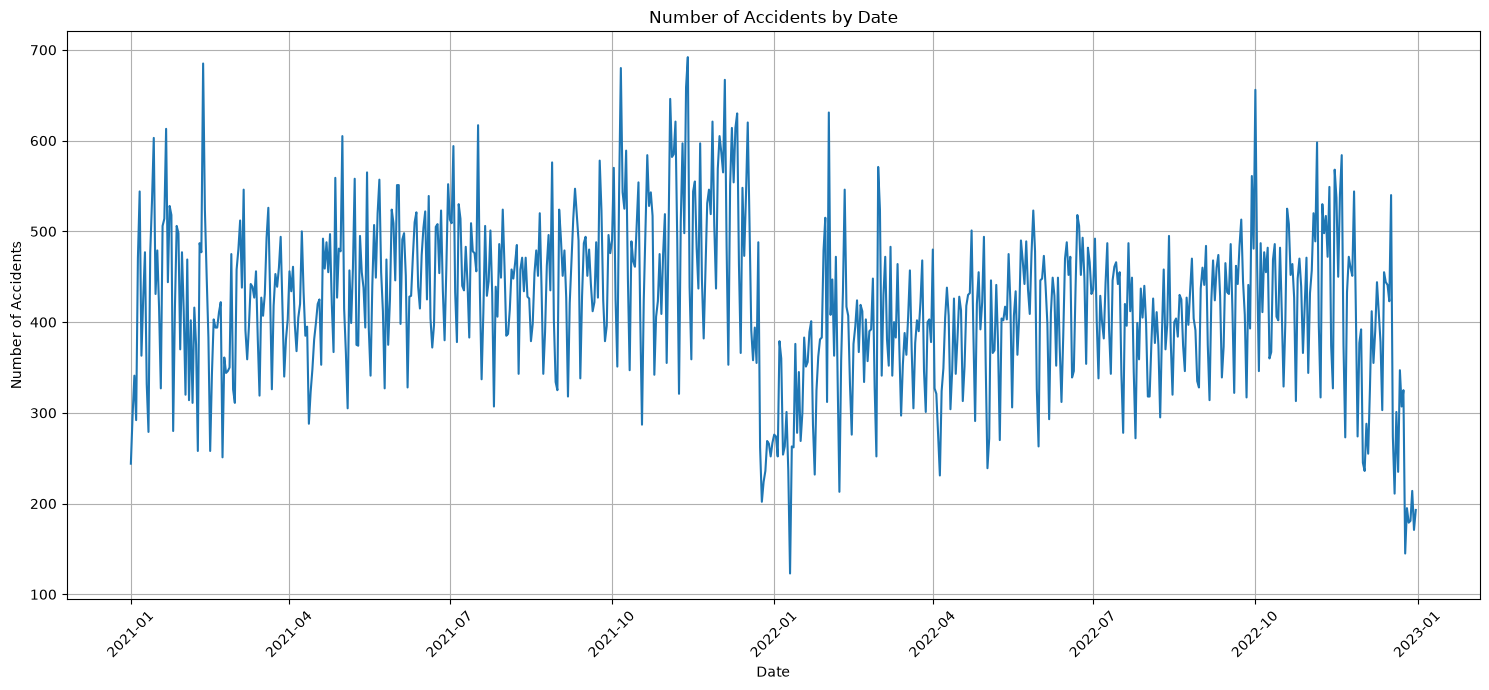

In [24]:
#Number of accidents by 'Accident Date'
df_accident_date = df_cleaned.groupby(df_cleaned['Accident Date'].dt.date).size()

# Plot
plt.figure(figsize=(15, 7))
plt.plot(df_accident_date.index, df_accident_date.values, linestyle='-')
plt.title('Number of Accidents by Date')
plt.xlabel('Date')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

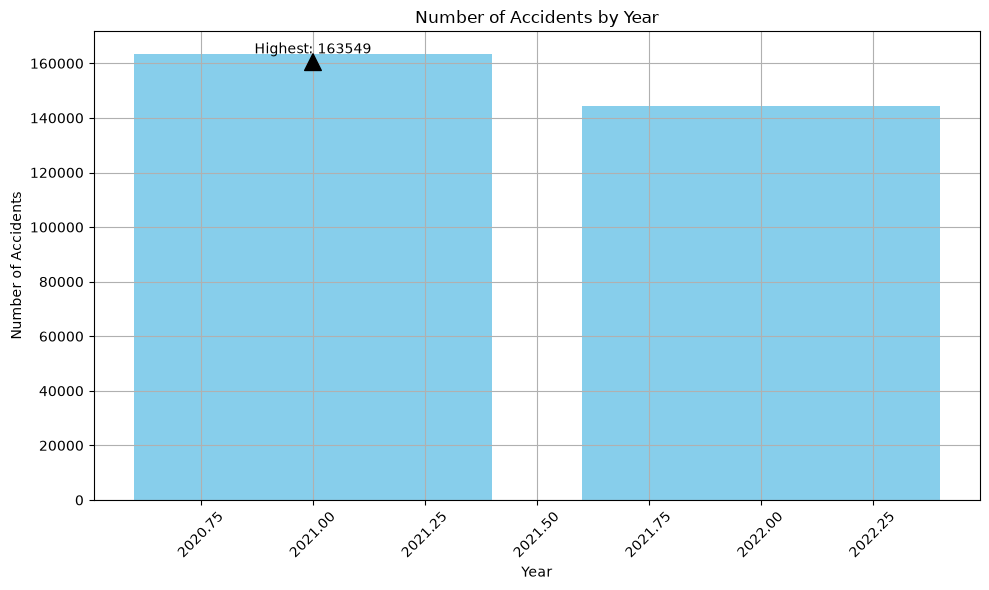

The year with the highest number of accidents is 2021 with 163549 accidents.


In [25]:
# Extracting the year from the 'Accident Date'
df_cleaned['Year'] = df_cleaned['Accident Date'].dt.year

# Group by year and count the number of accidents
df_yearly_accidents = df_cleaned.groupby('Year').size()

# Find the year with the highest number of accidents
most_accidents_year = df_yearly_accidents.idxmax()
most_accidents_count = df_yearly_accidents.max()

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(df_yearly_accidents.index, df_yearly_accidents.values, color='skyblue')
plt.title('Number of Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

# Annotating the bar with the highest number of accidents
plt.annotate(f'Highest: {most_accidents_count}',
             xy=(most_accidents_year, most_accidents_count),
             xytext=(most_accidents_year, most_accidents_count + 100),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center')

plt.tight_layout()
plt.grid()
plt.show()

print(f'The year with the highest number of accidents is {most_accidents_year} with {most_accidents_count} accidents.')

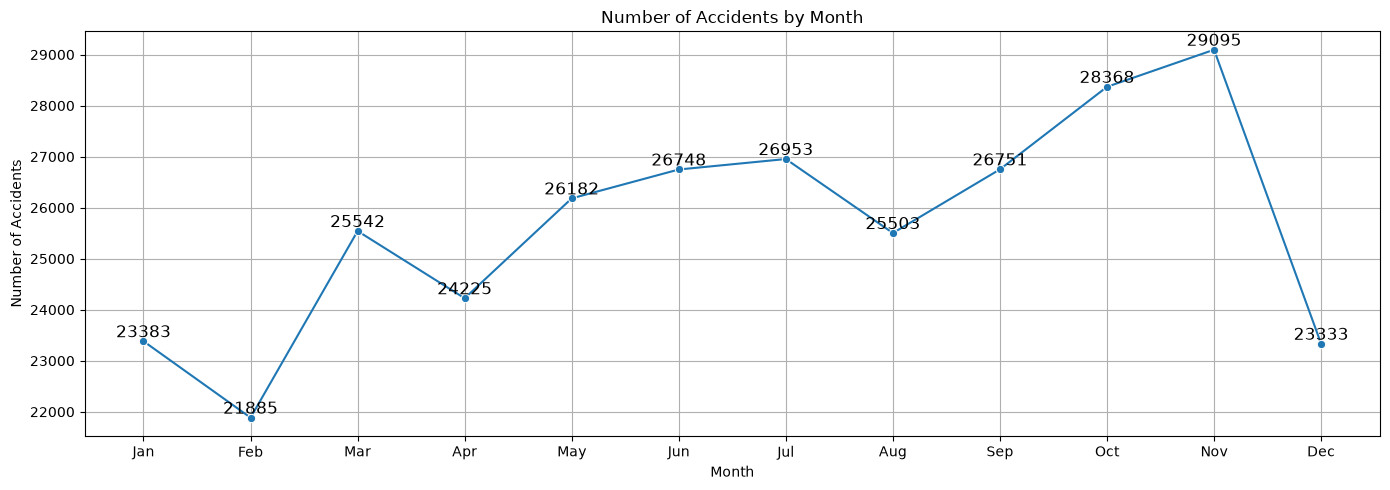

In [26]:
# Aggregating the number of accidents by month
monthly_accidents = df_cleaned.groupby('Month').size().reset_index(name='Number_of_Accidents')

# Plot
plt.figure(figsize=(14, 5))
line_plot = sns.lineplot(data=monthly_accidents, x='Month', y='Number_of_Accidents', marker='o', palette='pastel')

# Annotating data points
for i in range(len(monthly_accidents)):
    plt.text(x=monthly_accidents['Month'].iloc[i],
             y=monthly_accidents['Number_of_Accidents'].iloc[i],
             s=monthly_accidents['Number_of_Accidents'].iloc[i],
             ha='center', va='bottom', fontsize=12, color='black')

plt.title('Number of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.grid()
plt.show()

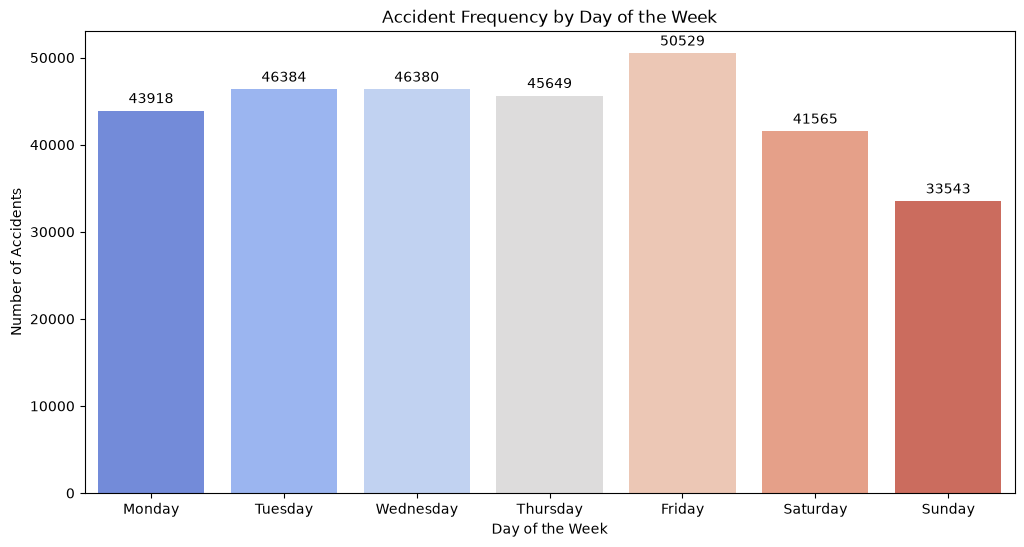

In [27]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_cleaned, x='Day_of_Week', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='coolwarm')

# Annotating the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '0.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 8),
                textcoords = 'offset points')

plt.title('Accident Frequency by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.show()


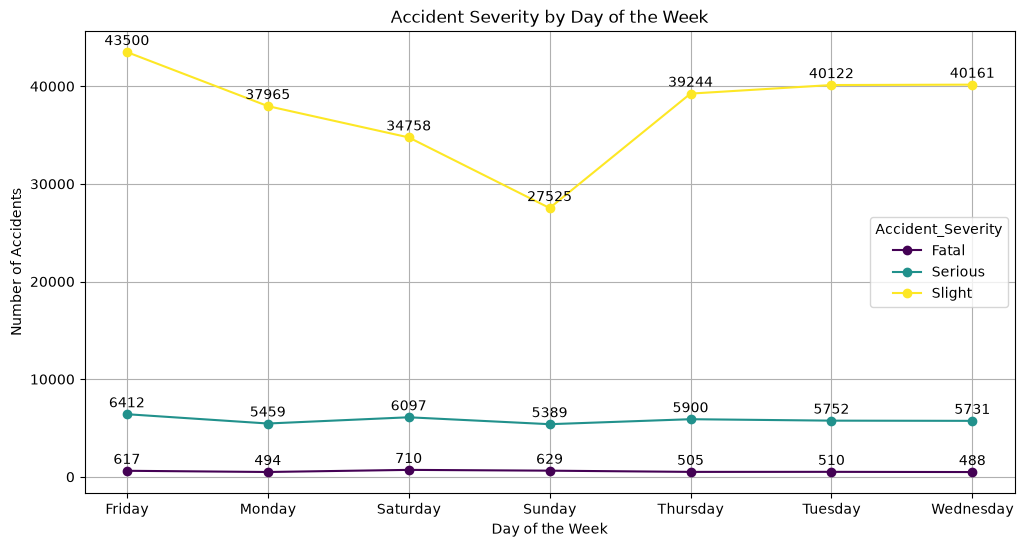

In [28]:
# Grouping by Day of Week and Severity
day_severity = df_cleaned.groupby(['Day_of_Week', 'Accident_Severity']).size().reset_index(name='Count')

# Pivot the data for visualization
day_severity_pivot = day_severity.pivot(index='Day_of_Week', columns='Accident_Severity', values='Count').fillna(0)

# Plotting
ax = day_severity_pivot.plot(kind='line', figsize=(12, 6), marker='o', colormap='viridis')

# Annotating the lines
for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    for x, y in zip(x_data, y_data):
        ax.annotate(f'{int(y)}',
                    (x, y),
                    textcoords="offset points",
                    xytext=(0, 5),
                    ha='center')

plt.title('Accident Severity by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

## time


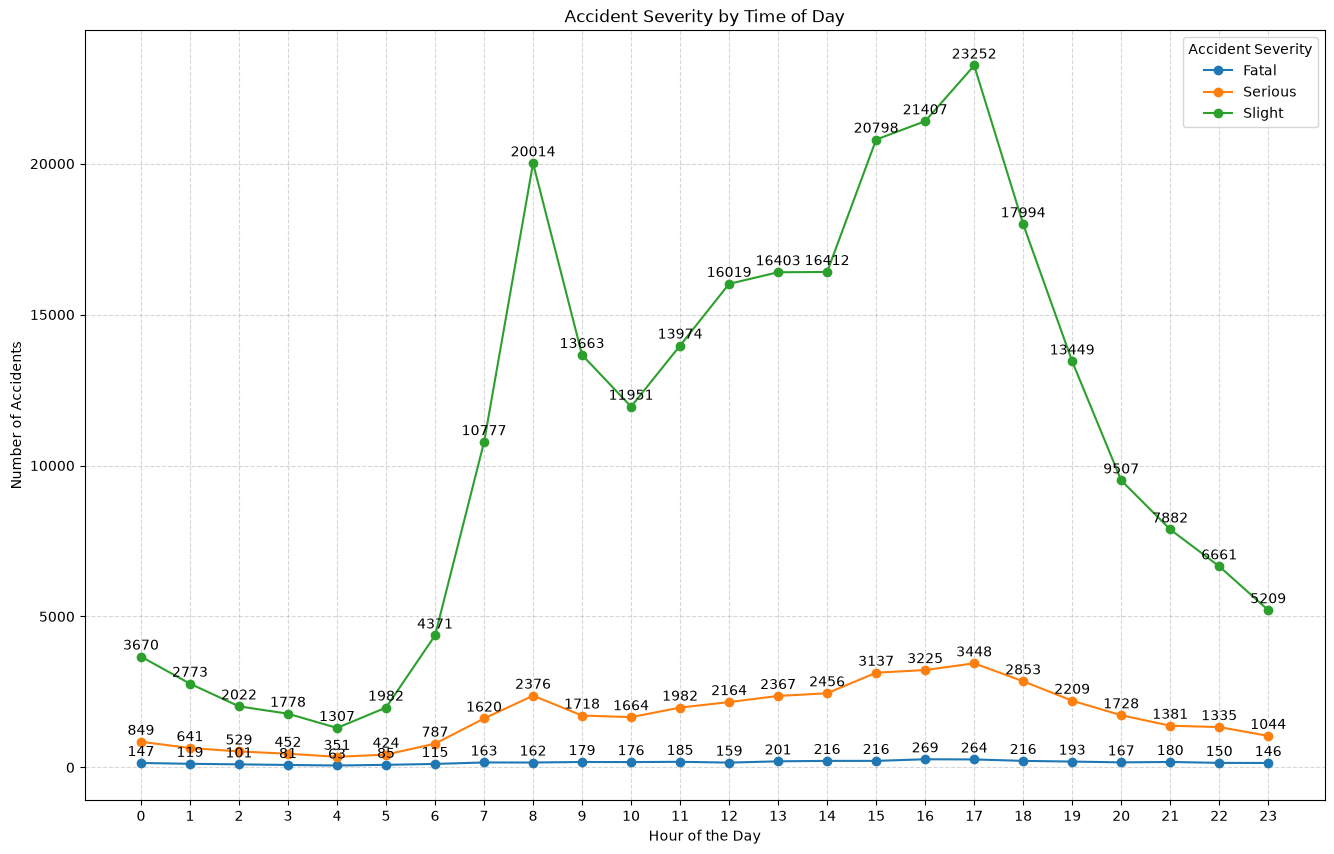

In [29]:
# Grouping by hour and accident severity
severity_by_hour = df_cleaned.groupby(['Hour', 'Accident_Severity']).size().unstack()

# Plotting the line plot for each severity level
plt.figure(figsize=(16, 10))
for severity in severity_by_hour.columns:
    plt.plot(severity_by_hour.index, severity_by_hour[severity], label=severity, marker='o')

    # Annotating the lines
    for x, y in zip(severity_by_hour.index, severity_by_hour[severity]):
        plt.annotate(f'{int(y)}',
                     (x, y),
                     textcoords="offset points",
                     xytext=(0, 5),
                     ha='center')

plt.title('Accident Severity by Time of Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Accident Severity', loc='upper right')
plt.show()

## junction control

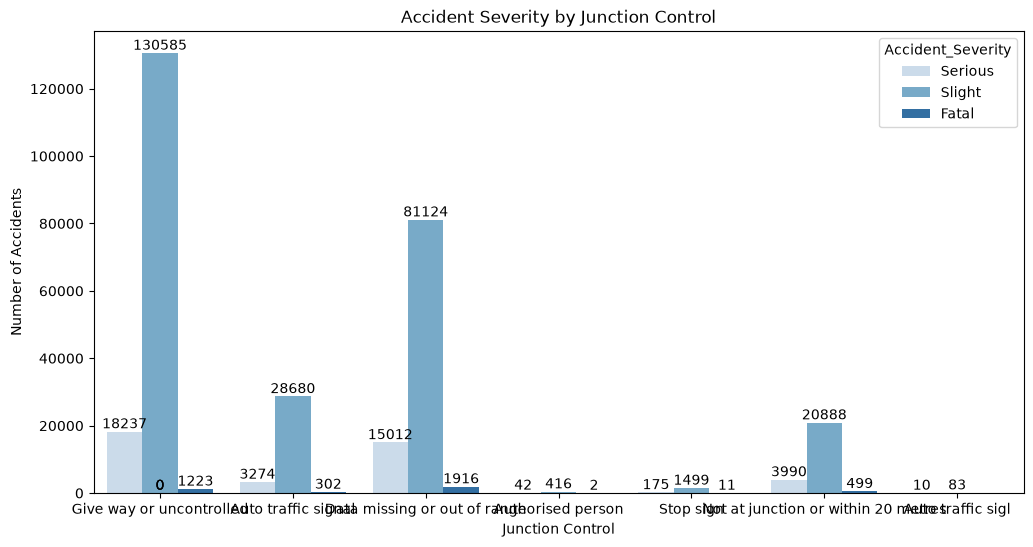

In [30]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='Junction_Control', hue='Accident_Severity', data=df_cleaned, palette='Blues')

# Annotating the bars
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(format(height, '.0f'),
                (patch.get_x() + patch.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Accident Severity by Junction Control')
plt.xlabel('Junction Control')
plt.ylabel('Number of Accidents')
plt.show()

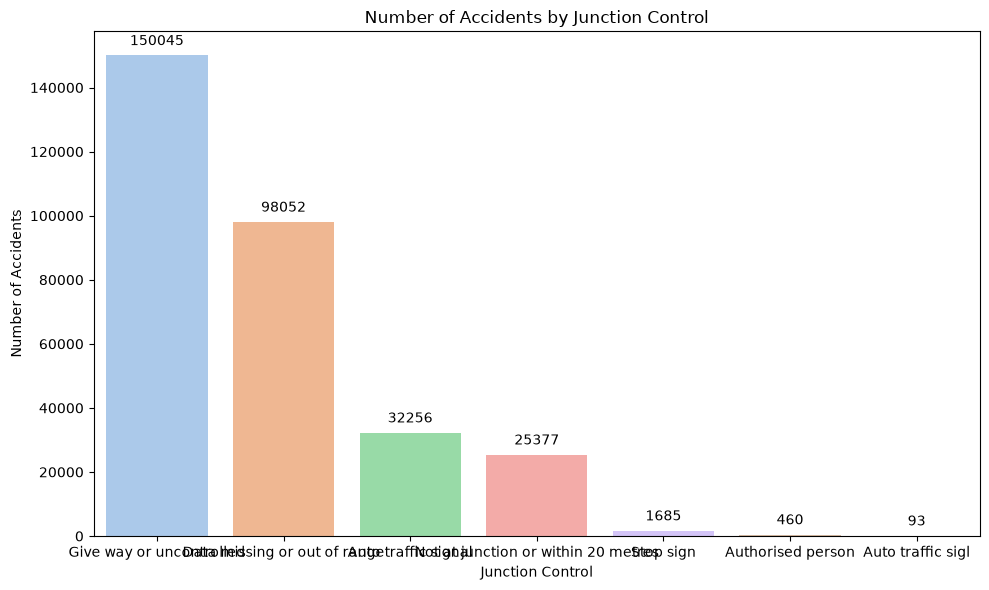

In [31]:
# Number of accidents by 'Junction_Control'
df_junction_control = df_cleaned.groupby('Junction_Control').size().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=df_junction_control.index, y=df_junction_control.values, palette='pastel')

# Annotate the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Number of Accidents by Junction Control')
plt.xlabel('Junction Control')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()


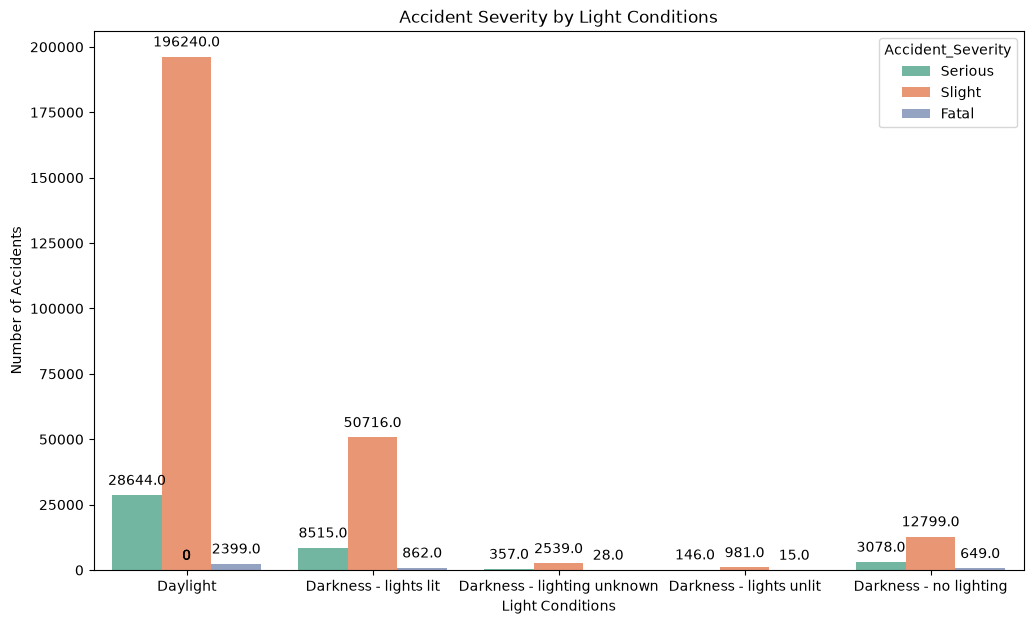

In [32]:
plt.figure(figsize=(12, 7))
ax = sns.countplot(x='Light_Conditions', hue='Accident_Severity', data=df_cleaned, palette='Set2')

# Annotating the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Accident Severity by Light Conditions')
plt.xlabel('Light Conditions')
plt.ylabel('Number of Accidents')
plt.show()

In [33]:
# No. of accidents in urban and rural areas
accident_no = df_cleaned.groupby('Urban_or_Rural_Area')['Accident_Severity'].count()
accident_no

Urban_or_Rural_Area
Rural    109436
Urban    198532
Name: Accident_Severity, dtype: int64

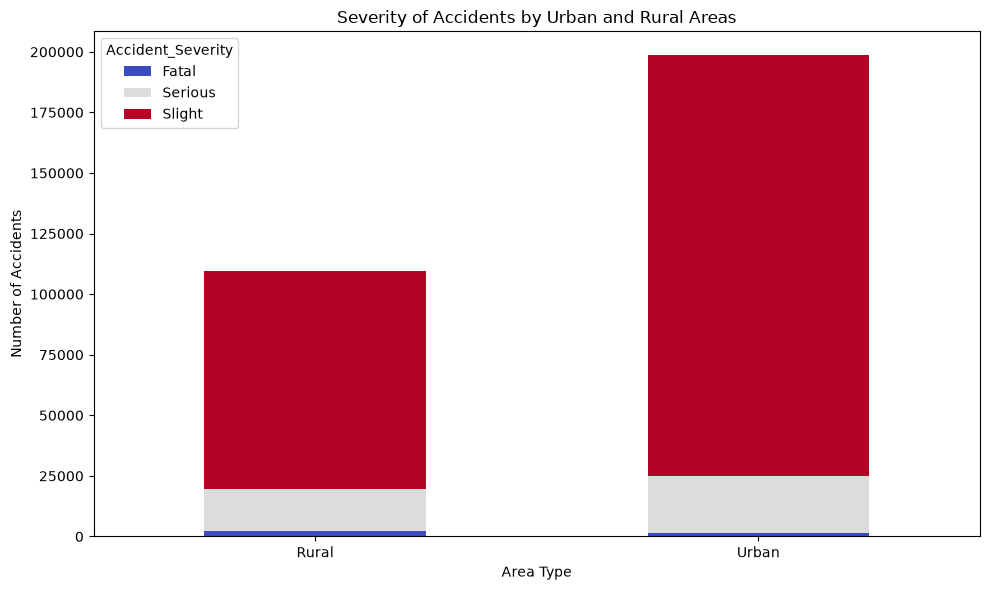

In [34]:
# Grouping by 'Urban_or_Rural_Area' and 'Accident_Severity'
severity_by_area = df_cleaned.groupby(['Urban_or_Rural_Area', 'Accident_Severity']).size().reset_index(name='Count')

# Pivot to arrange data for plotting
severity_pivot = severity_by_area.pivot(index='Urban_or_Rural_Area', columns='Accident_Severity', values='Count').fillna(0)

# Plotting a stacked bar chart
severity_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')

plt.title('Severity of Accidents by Urban and Rural Areas')
plt.xlabel('Area Type')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

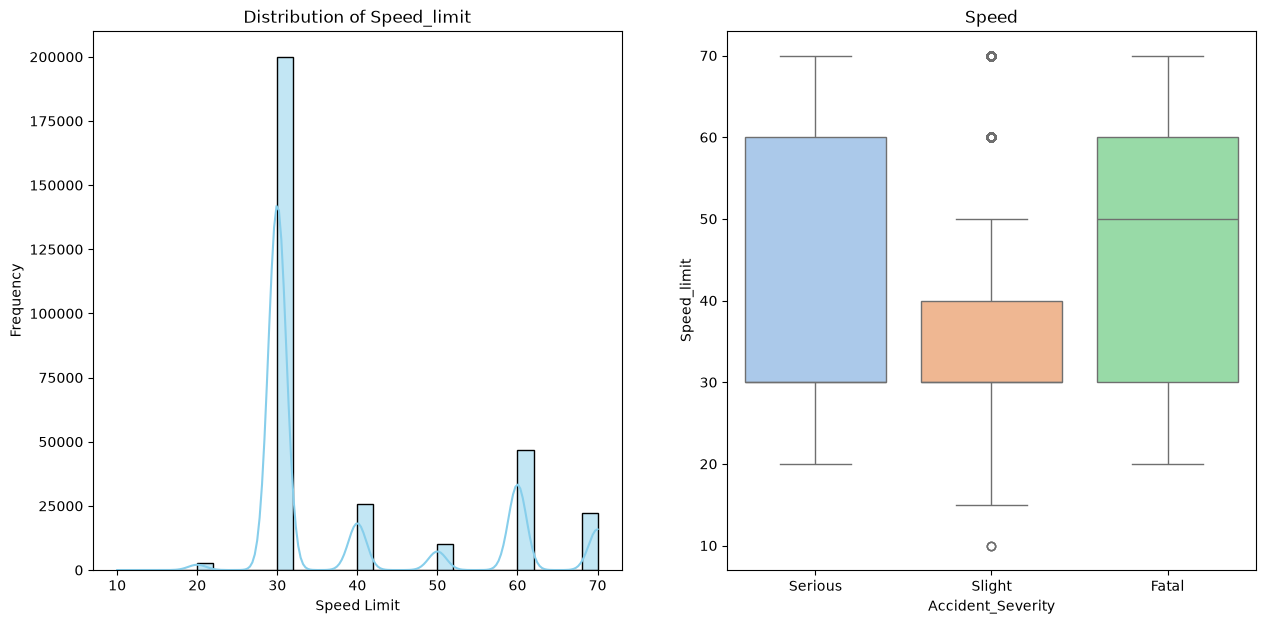

In [35]:
# Visualization for 'Speed_limit'
plt.figure(figsize=(15, 7))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['Speed_limit'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Speed_limit')
plt.xlabel('Speed Limit')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x='Accident_Severity', y='Speed_limit', data=df_cleaned, palette='pastel')
plt.title('Speed')
plt.show()

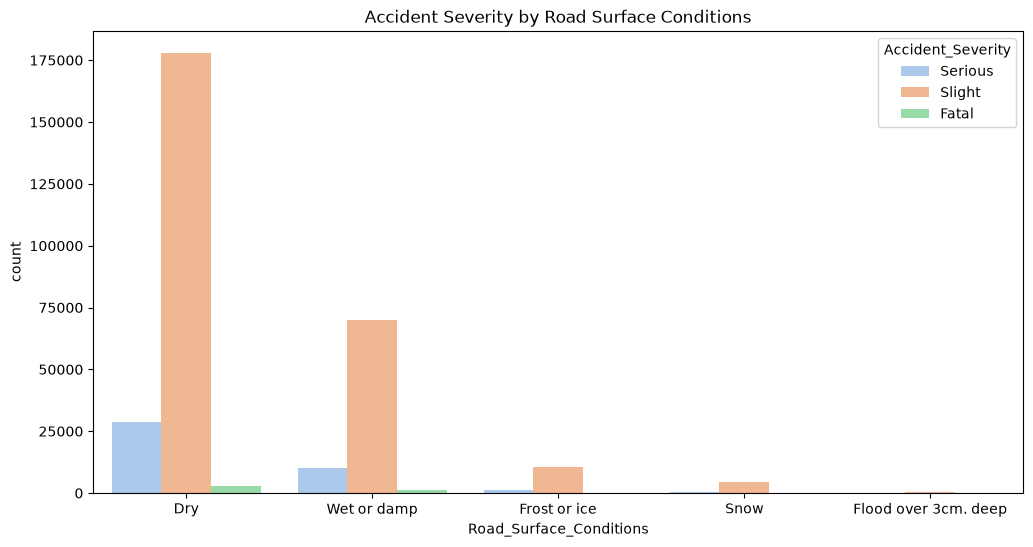

In [36]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Road_Surface_Conditions', hue='Accident_Severity', data=df_cleaned, palette='pastel')
plt.title('Accident Severity by Road Surface Conditions')
plt.show()

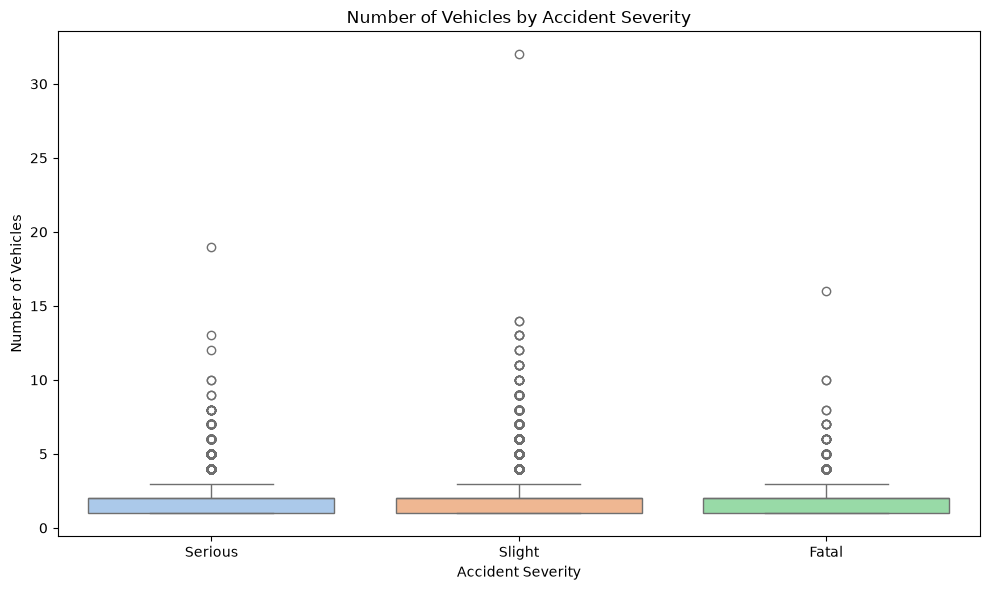

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Accident_Severity',
    y='Number_of_Vehicles',
    data=df_cleaned,
    palette='pastel'
)

plt.title('Number of Vehicles by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()

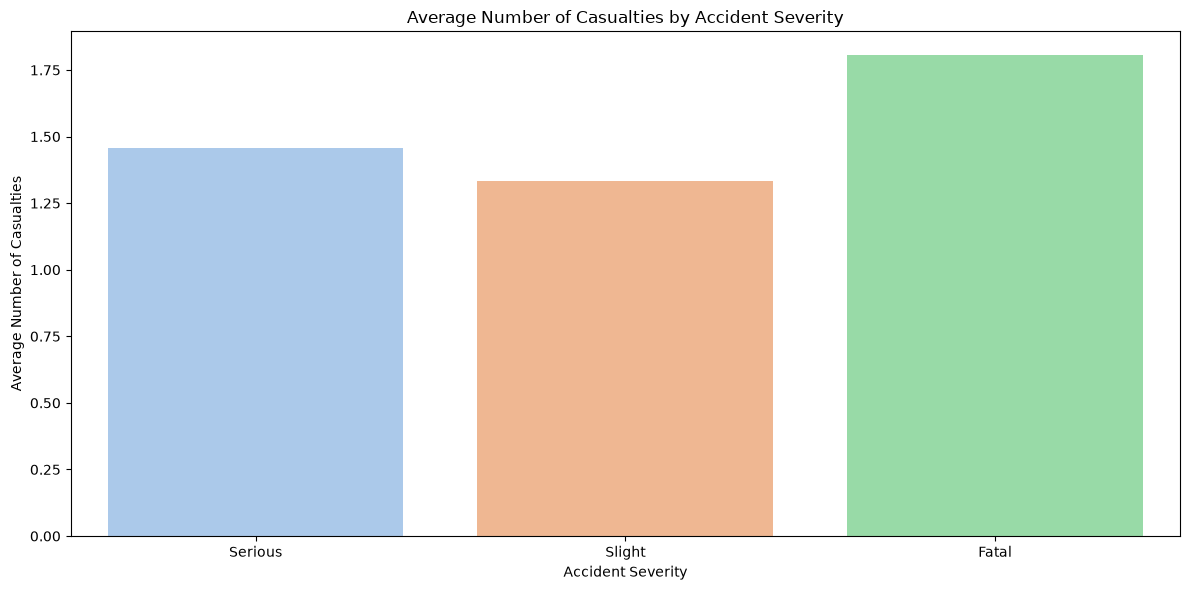

In [38]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x='Accident_Severity',
    y='Number_of_Casualties',
    data=df_cleaned,
    palette='pastel',
    errorbar=None
)

plt.title('Average Number of Casualties by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Average Number of Casualties')
plt.tight_layout()
plt.show()

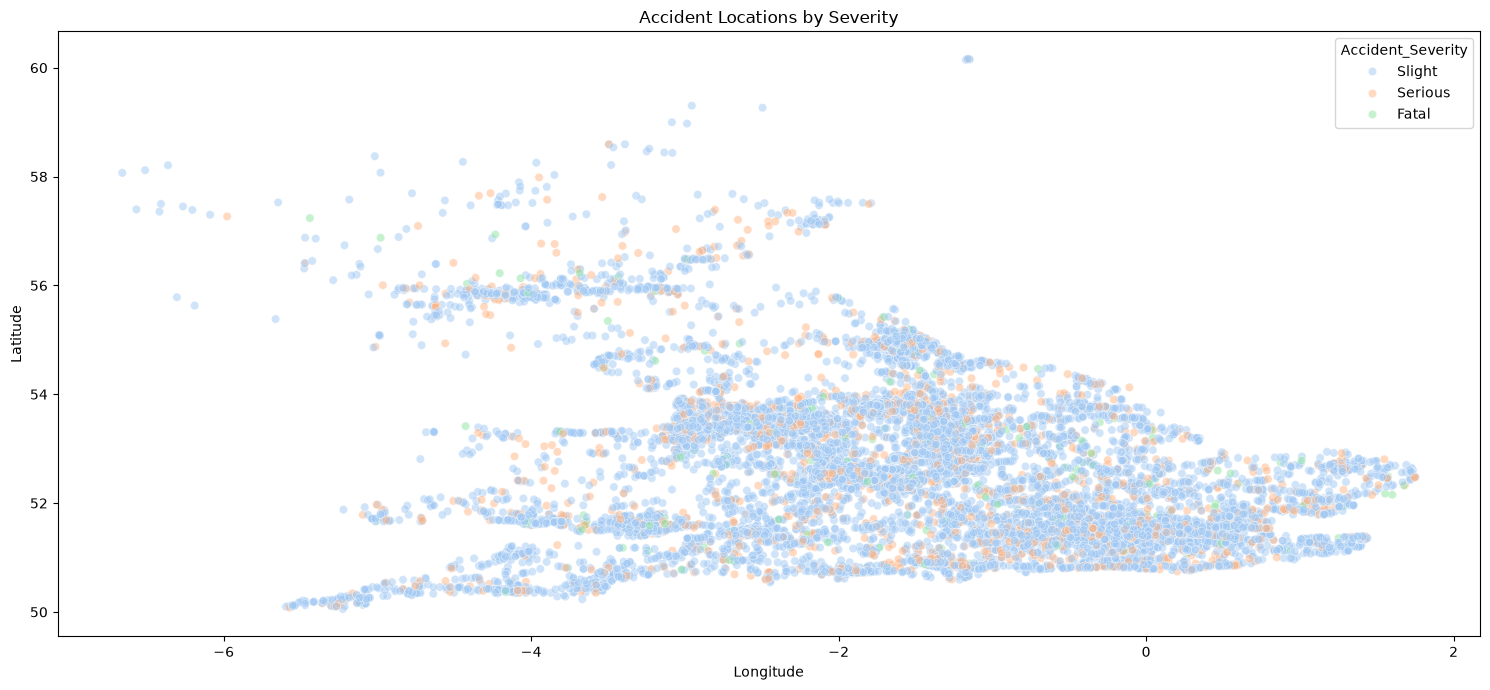

In [39]:
plt.figure(figsize=(15, 7))

sns.scatterplot(
    x='Longitude',
    y='Latitude',
    data=df_cleaned.sample(20000, random_state=42),
    hue='Accident_Severity',
    alpha=0.5,
    palette='pastel'
)

plt.title('Accident Locations by Severity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## Data Preprocessing


In [40]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 307968 entries, 0 to 307972
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Accident Date               307968 non-null  datetime64[us]
 1   Day_of_Week                 307968 non-null  str           
 2   Junction_Control            307968 non-null  str           
 3   Junction_Detail             307968 non-null  str           
 4   Accident_Severity           307968 non-null  str           
 5   Latitude                    307968 non-null  float64       
 6   Light_Conditions            307968 non-null  str           
 7   Local_Authority_(District)  307968 non-null  str           
 8   Longitude                   307968 non-null  float64       
 9   Number_of_Casualties        307968 non-null  int64         
 10  Number_of_Vehicles          307968 non-null  int64         
 11  Police_Force                307968 non-null  str       

# feature engineering


In [41]:
df_cleaned['Casualty_Vehicle_Ratio'] = df_cleaned['Number_of_Casualties'] / df_cleaned['Number_of_Vehicles']

In [42]:
df_cleaned['Weather_Road_Interaction'] = df_cleaned['Weather_Conditions'].astype(str) + "_" + df_cleaned['Road_Surface_Conditions'].astype(str)

# encoding 

In [43]:
df_cleaned['Accident_Severity'].value_counts()

Accident_Severity
Slight     263275
Serious     40740
Fatal        3953
Name: count, dtype: int64

In [44]:
df_cleaned['Slight'].value_counts()

Slight
1    263275
0     44693
Name: count, dtype: int64

# Cyclic Encoding


In [45]:
day_map = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7}

df_cleaned['Day_of_Week'] = df_cleaned['Day_of_Week'].map(day_map)

df_cleaned['Day_of_Week_sin'] = np.sin(2 * np.pi * df_cleaned['Day_of_Week'] / 7)
df_cleaned['Day_of_Week_cos'] = np.cos(2 * np.pi * df_cleaned['Day_of_Week'] / 7)

df_cleaned.drop('Day_of_Week', axis=1, inplace=True)

## Manual Label Encoding

In [46]:
severity_map = {'Slight':1,'Serious':2, 'Fatal':3}
light_Conditions_map = {'Daylight': 1, 'Dark_Lit': 2, 'Dark_Unknown': 3, 'Dark_unlit': 4, 'Dark_No_Light': 5}
area_map = {'Urban':-0.5, 'Rural':0.5}

In [47]:
df_cleaned['Accident_Severity'] = df_cleaned['Accident_Severity'].map(severity_map)
df_cleaned['Light_Conditions'] = df_cleaned['Light_Conditions'].map(light_Conditions_map)
df_cleaned['Urban_or_Rural_Area'] = df_cleaned['Urban_or_Rural_Area'].map(area_map)

# One Hot Encoder

In [48]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=[
        'Junction_Control',
        'Junction_Detail',
        'Road_Surface_Conditions',
        'Road_Type',
        'Weather_Conditions',
        'Vehicle_Type',
        'Weather_Road_Interaction'
    ]
)

## Target Encoding

In [49]:
encoder = TargetEncoder(cols=['Local_Authority_(District)', 'Police_Force'])
df_cleaned = encoder.fit_transform(df_cleaned, df_cleaned['Accident_Severity'])

## Feature Selection


In [50]:
def drop_low_correlated_columns(df, threshold=0.4):
  # Calculate the correlation matrix
  df_copy = df.copy()
  corr_matrix = df_copy.corr().abs()

  # Get the columns to drop
  columns_to_drop = []
  for i, col in enumerate(corr_matrix.columns):
    for j in range(i+1, len(corr_matrix.columns)):
      if abs(corr_matrix.iloc[i, j]) >= threshold:
        columns_to_drop.append(col)
        break

  # Drop the columns
  df_filtered = df_copy.drop(columns_to_drop, axis=1)

  return df_filtered

In [51]:
def drop_collinear_columns(df, threshold=0.8):
    # Compute the correlation matrix
    df_copy = df.copy()
    corr_matrix = df.corr().abs()

    # Create an upper triangle matrix to avoid double-counting pairs
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Identify columns to drop (where correlation exceeds the threshold)
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

    # Drop the collinear columns
    df_reduced = df.drop(columns=to_drop)
    
    return df_reduced

# splitting


In [52]:
X1 = drop_collinear_columns(drop_low_correlated_columns(df_cleaned.drop(['Accident_Severity','Accident Date', 'Time','Slight'], axis=1)))
Y1 = df_cleaned['Slight']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,Y1, stratify=Y1, test_size = 0.2, random_state = 42)

In [53]:
df2_cleaned = df_cleaned[df_cleaned['Slight'] == 0]

In [54]:
X2 = drop_collinear_columns(drop_low_correlated_columns(df2_cleaned.drop(['Accident_Severity','Accident Date', 'Time','Slight'], axis=1)))
Y2 = df2_cleaned['Accident_Severity']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,Y2, stratify=Y2, test_size = 0.2, random_state = 42)

In [55]:
y1_train.value_counts()

Slight
1    210620
0     35754
Name: count, dtype: int64

In [57]:
print(X1_train.isna().sum()[X1_train.isna().sum() > 0])

Light_Conditions    64372
dtype: int64


In [58]:
X1_train['Light_Conditions'] = X1_train['Light_Conditions'].fillna(
    X1_train['Light_Conditions'].mode()[0]
)

X1_test['Light_Conditions'] = X1_test['Light_Conditions'].fillna(
    X1_train['Light_Conditions'].mode()[0]
)

## Resampling

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X2_train_standard = scaler.fit_transform(X2_train_resampled)
X2_test_standard = scaler.transform(X2_test_imputed)

In [59]:
adasyn = ADASYN()                                           # Generating synthetic samples in regions of Not Slight
X1_train_resampled, y1_train_resampled = adasyn.fit_resample(X1_train, y1_train)
X1_train_resampled, y1_train_resampled = X1_train, y1_train

In [60]:
y1_train_resampled.value_counts()

Slight
1    210620
0     35754
Name: count, dtype: int64

In [ ]:
tl = TomekLinks()                                           # To remove noisy data
X2_train_imputed = X2_train.fillna(X2_train.median())
X2_train_resampled, y2_train_resampled = tl.fit_resample(X2_train_imputed, y2_train)
adasyn = ADASYN()                                           # Generating synthetic samples in regions of Not Slight
X2_train_resampled, y2_train_resampled = adasyn.fit_resample(X2_train_resampled, y2_train_resampled)

ValueError: Input X contains NaN.
TomekLinks does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y2_train_resampled.value_counts()

Accident_Severity
2    31432
3    31104
Name: count, dtype: int64

## scaling

In [ ]:
### Min-Max Scaler (Normalization)

In [ ]:
scaler_min_max = MinMaxScaler()

X1_train_normalized = scaler_min_max.fit_transform(X1_train)
X1_test_normalized = scaler_min_max.transform(X1_test)

In [ ]:
scaler_min_max = MinMaxScaler()

X2_train_normalized = scaler_min_max.fit_transform(X2_train)
X2_test_normalized = scaler_min_max.transform(X2_test)

### Standard Scaler


In [ ]:
standard_scaler = StandardScaler()
X1_train_standard = standard_scaler.fit_transform(X1_train_resampled)
X1_test_standard = standard_scaler.transform(X1_test)

In [ ]:
standard_scaler = StandardScaler()
X2_train_standard = standard_scaler.fit_transform(X2_train_resampled)
X2_test_standard = standard_scaler.transform(X2_test)

### RobustScaler

In [ ]:
scaler_robust = RobustScaler()
X1_train_robust = scaler_robust.fit_transform(X1_train_resampled)
X1_test_robust = scaler_robust.transform(X1_test)

In [ ]:
scaler_robust = RobustScaler()
X2_train_robust = scaler_robust.fit_transform(X2_train_resampled)
X2_test_robust = scaler_robust.transform(X2_test)

In [ ]:
X1_train['Light_Conditions'] = X1_train['Light_Conditions'].fillna(
    X1_train['Light_Conditions'].mode()[0]
)

X1_test['Light_Conditions'] = X1_test['Light_Conditions'].fillna(
    X1_train['Light_Conditions'].mode()[0]
)

## Modelling 1

In [ ]:
def evaluate_model(model,x_train,y_test,y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f'Train score: {model.score(x_train,y1_train_resampled)* 100:.2f}%\n')
    print(f'Accuracy: {accuracy * 100:.2f}%\n')

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    print('Classification Report:')
    print(class_report)

## Logistic Regression

### standard

Train score: 68.01%

Accuracy: 62.88%



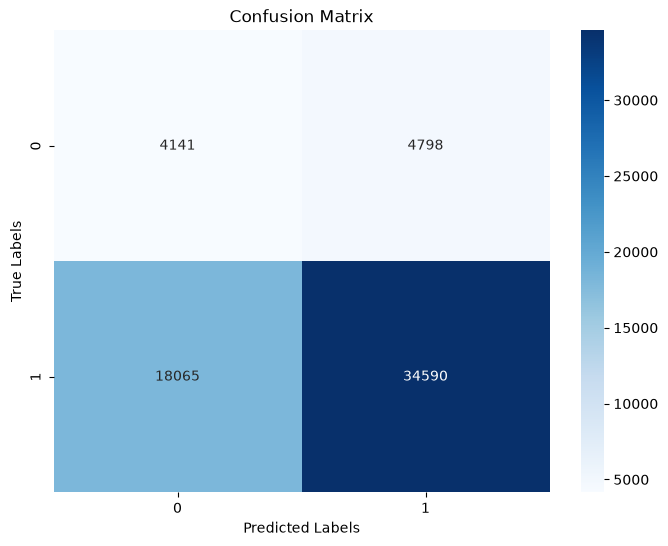

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.46      0.27      8939
           1       0.88      0.66      0.75     52655

    accuracy                           0.63     61594
   macro avg       0.53      0.56      0.51     61594
weighted avg       0.78      0.63      0.68     61594



In [ ]:
model = LogisticRegression(C=0.02, solver='liblinear', penalty='l1', max_iter=5000)
model.fit(X1_train_standard, y1_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X1_test_standard)

# Evaluate the model
evaluate_model(model,X1_train_standard,y1_test,y_pred)

## Decision Tree

### standard scaller

Train score: 78.70%

Accuracy: 71.50%



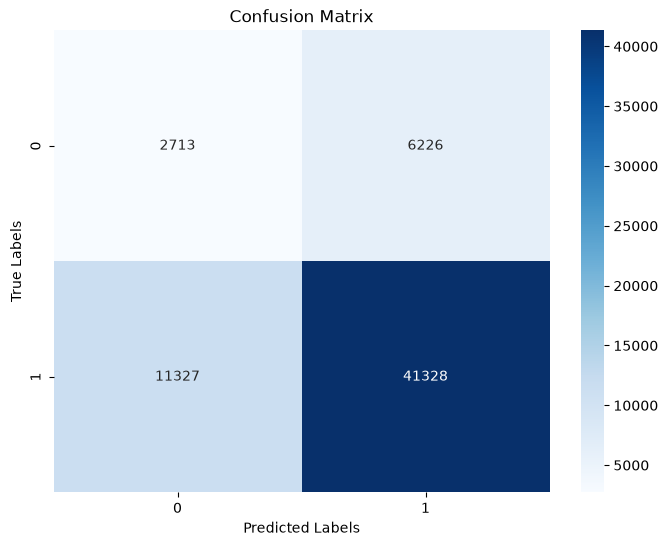

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.30      0.24      8939
           1       0.87      0.78      0.82     52655

    accuracy                           0.72     61594
   macro avg       0.53      0.54      0.53     61594
weighted avg       0.77      0.72      0.74     61594



In [ ]:
model = DecisionTreeClassifier(criterion='entropy', max_features='sqrt', min_samples_leaf=2, min_samples_split=7,
                               splitter='random',random_state=42)

model.fit(X1_train_standard, y1_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X1_test_standard)

# Evaluate the model
evaluate_model(model,X1_train_standard,y1_test,y_pred)


### Min-Max Scaling (Normalization)

Train score: 72.23%

Accuracy: 63.59%



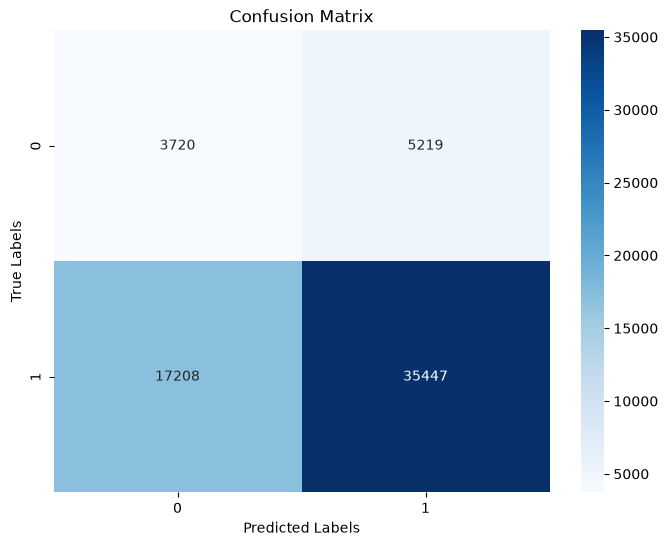

Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.42      0.25      8939
           1       0.87      0.67      0.76     52655

    accuracy                           0.64     61594
   macro avg       0.52      0.54      0.50     61594
weighted avg       0.77      0.64      0.69     61594



In [ ]:
model = DecisionTreeClassifier(criterion='gini', max_depth=13, max_features='sqrt', min_samples_leaf=1, min_samples_split=9,
                               splitter='best',random_state=42)

model.fit(X1_train_robust, y1_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X1_test_standard)

# Evaluate the model
evaluate_model(model,X1_train_robust,y1_test,y_pred)

## Random Forest

### Standard Scaler

Train score: 100.00%

Accuracy: 84.02%



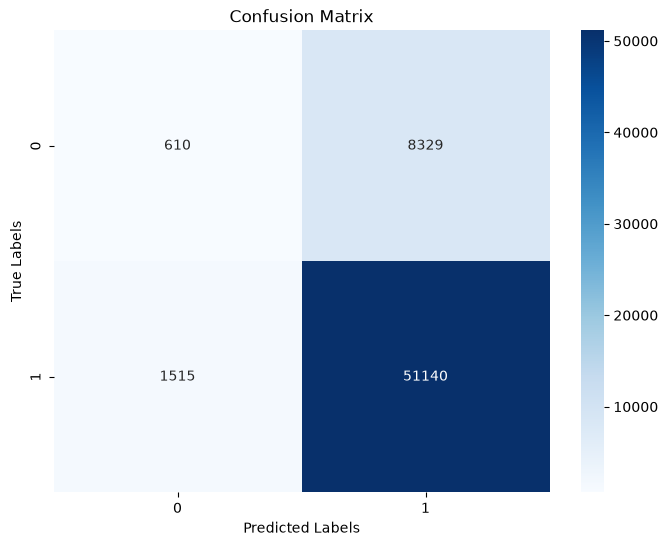

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.07      0.11      8939
           1       0.86      0.97      0.91     52655

    accuracy                           0.84     61594
   macro avg       0.57      0.52      0.51     61594
weighted avg       0.78      0.84      0.80     61594



In [ ]:
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X1_train_standard, y1_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X1_test_standard)

# Evaluate the model
evaluate_model(model,X1_train_standard,y1_test,y_pred)

### Robust Scaling

Train score: 100.00%

Accuracy: 84.02%



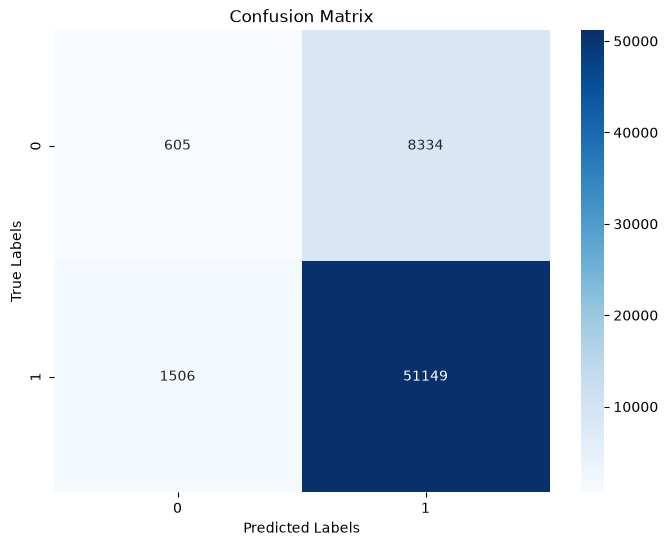

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.07      0.11      8939
           1       0.86      0.97      0.91     52655

    accuracy                           0.84     61594
   macro avg       0.57      0.52      0.51     61594
weighted avg       0.78      0.84      0.80     61594



In [ ]:
model = RandomForestClassifier(bootstrap=True, n_estimators=300, random_state=42, criterion='gini')
model.fit(X1_train_robust, y1_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X1_test_robust)

# Evaluate the model
evaluate_model(model,X1_train_robust,y1_test,y_pred)

## XGBoost

Train score: 90.13%

Accuracy: 85.43%



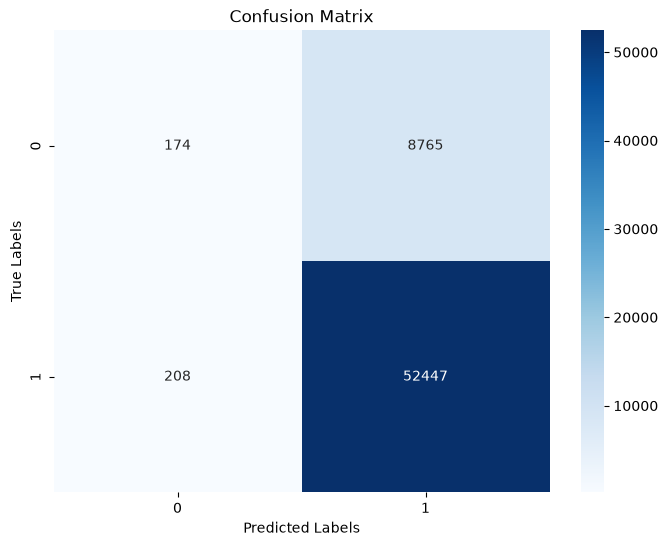

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.02      0.04      8939
           1       0.86      1.00      0.92     52655

    accuracy                           0.85     61594
   macro avg       0.66      0.51      0.48     61594
weighted avg       0.80      0.85      0.79     61594



In [ ]:
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')

model.fit(X1_train_standard, y1_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X1_test_standard)

# Evaluate the model
mse = mean_squared_error(y1_test, y_pred)
r2 = r2_score(y1_test, y_pred)
accuracy = accuracy_score(y1_test, y_pred)

evaluate_model(model,X1_train_standard,y1_test,y_pred)

Train score: 90.16%

Accuracy: 85.40%



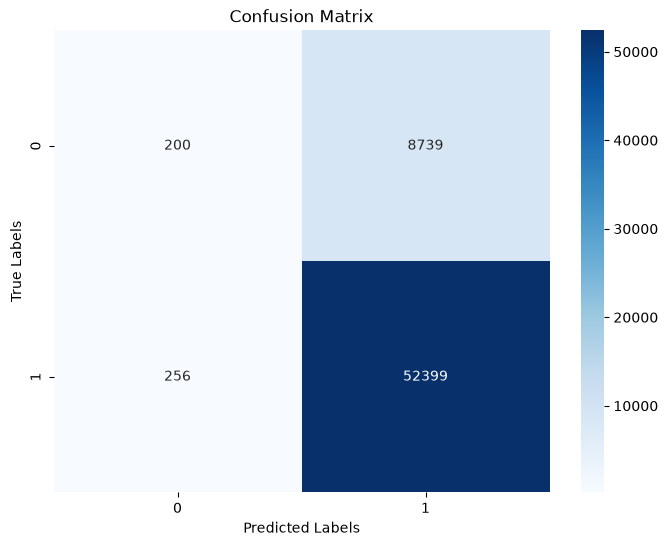

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.02      0.04      8939
           1       0.86      1.00      0.92     52655

    accuracy                           0.85     61594
   macro avg       0.65      0.51      0.48     61594
weighted avg       0.80      0.85      0.79     61594



In [ ]:
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')

model.fit(X1_train_robust, y1_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X1_test_robust)

# Evaluate the model
evaluate_model(model,X1_train_robust,y1_test,y_pred)

## Modeling X2

In [ ]:

def evaluate_model(model,x_train,y_test,y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f'Train score: {model.score(x_train,y2_train_resampled)* 100:.2f}%\n')
    print(f'Accuracy: {accuracy * 100:.2f}%\n')

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    print('Classification Report:')
    print(class_report)


## linear regression

### standard

Train score: 70.52%

Accuracy: 67.52%



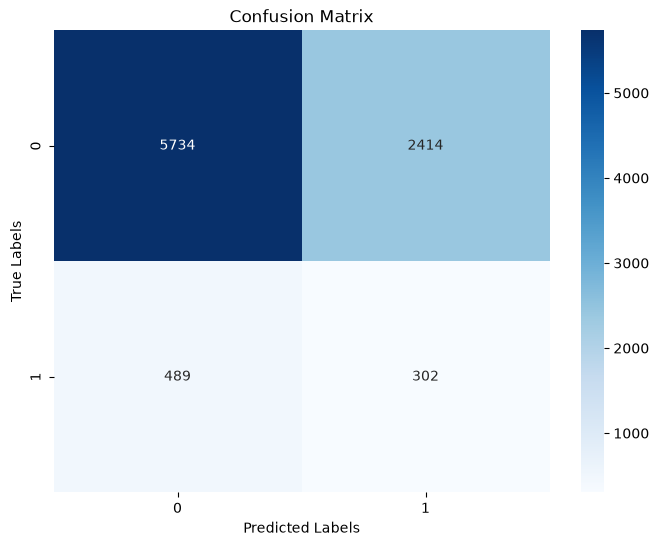

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.70      0.80      8148
           3       0.11      0.38      0.17       791

    accuracy                           0.68      8939
   macro avg       0.52      0.54      0.49      8939
weighted avg       0.85      0.68      0.74      8939



In [ ]:
model = LogisticRegression(C=0.1, solver='liblinear', penalty='l1', max_iter=5000)
model.fit(X2_train_standard, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_standard)

# Evaluate the model
evaluate_model(model,X2_train_standard,y2_test,y_pred)

Train score: 70.54%

Accuracy: 67.56%



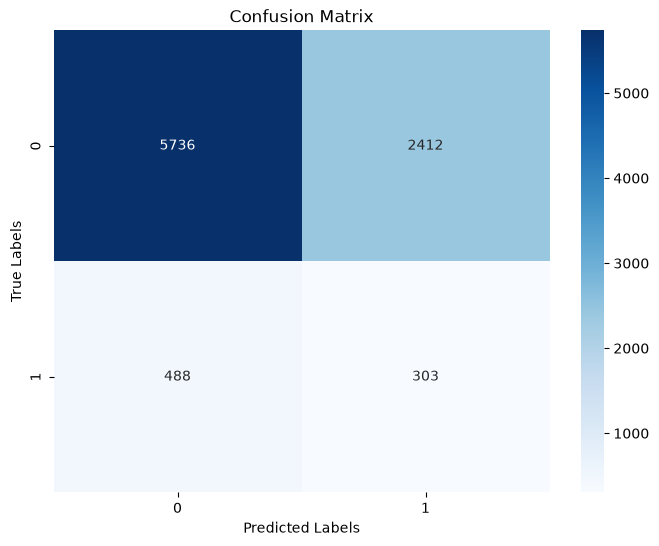

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.70      0.80      8148
           3       0.11      0.38      0.17       791

    accuracy                           0.68      8939
   macro avg       0.52      0.54      0.49      8939
weighted avg       0.85      0.68      0.74      8939



In [ ]:
model = LogisticRegression(C=0.1, solver='lbfgs', penalty='l2', max_iter=5000)
model.fit(X2_train_standard, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_standard)

# Evaluate the model
evaluate_model(model,X2_train_standard,y2_test,y_pred)

Train score: 70.53%

Accuracy: 67.56%



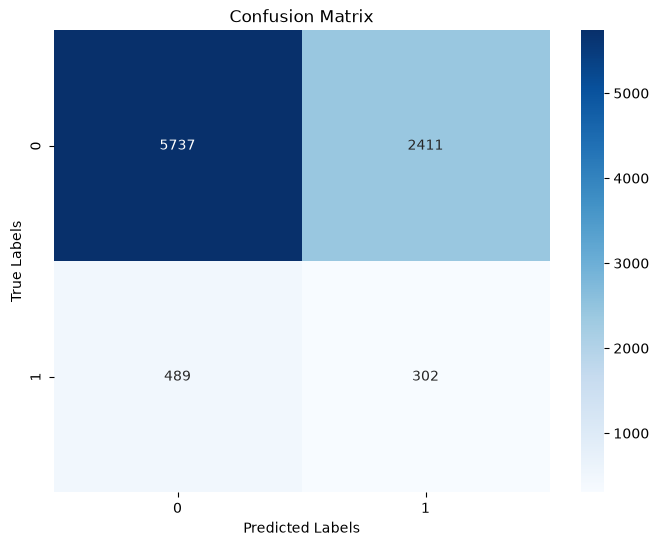

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.70      0.80      8148
           3       0.11      0.38      0.17       791

    accuracy                           0.68      8939
   macro avg       0.52      0.54      0.49      8939
weighted avg       0.85      0.68      0.74      8939



In [ ]:
model = LogisticRegression(max_iter=5000, solver='liblinear', penalty='l1', C=78.75)
model.fit(X2_train_robust, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_robust)

# Evaluate the model
evaluate_model(model,X2_train_robust,y2_test,y_pred)

Train score: 70.53%

Accuracy: 67.56%



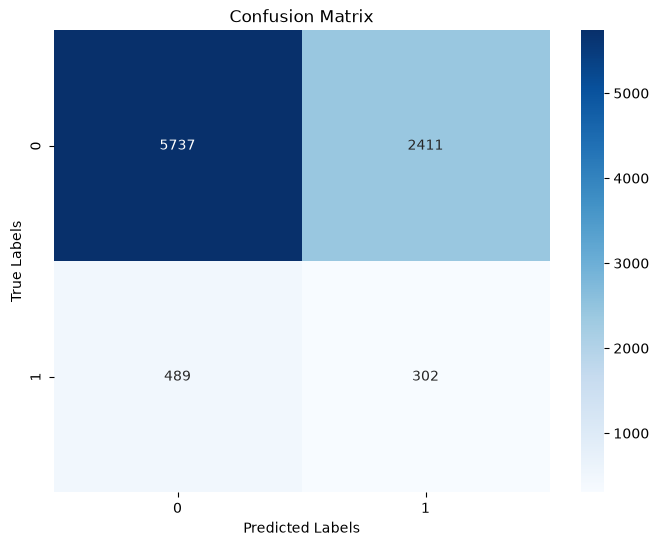

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.70      0.80      8148
           3       0.11      0.38      0.17       791

    accuracy                           0.68      8939
   macro avg       0.52      0.54      0.49      8939
weighted avg       0.85      0.68      0.74      8939



In [ ]:
model = LogisticRegression(max_iter=5000, solver='liblinear', penalty='l1', C=78.75)
model.fit(X2_train_robust, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_robust)

# Evaluate the model
evaluate_model(model,X2_train_robust,y2_test,y_pred)

## Decision Tree

### Standard Scaler


Train score: 81.43%

Accuracy: 74.71%



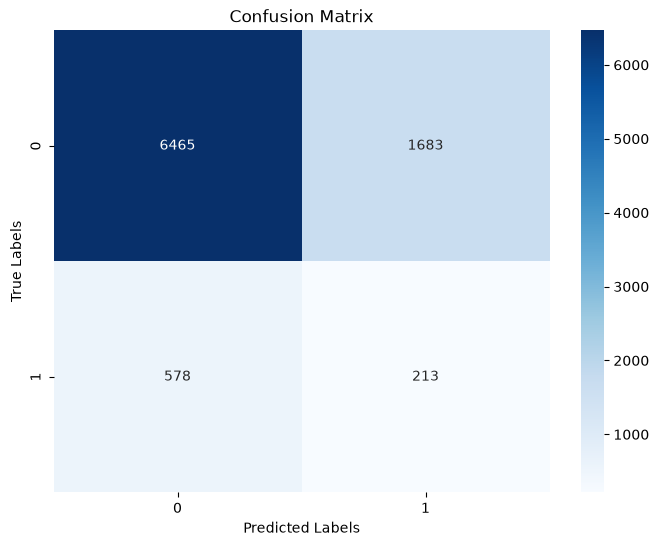

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.79      0.85      8148
           3       0.11      0.27      0.16       791

    accuracy                           0.75      8939
   macro avg       0.52      0.53      0.50      8939
weighted avg       0.85      0.75      0.79      8939



In [ ]:
model = DecisionTreeClassifier(criterion='entropy', max_features='sqrt', min_samples_leaf=2, min_samples_split=7,
                               splitter='random',random_state=42)

model.fit(X2_train_standard, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_standard)

# Evaluate the model
evaluate_model(model,X2_train_standard,y2_test,y_pred)

### Robust Scaler

Train score: 77.91%

Accuracy: 66.54%



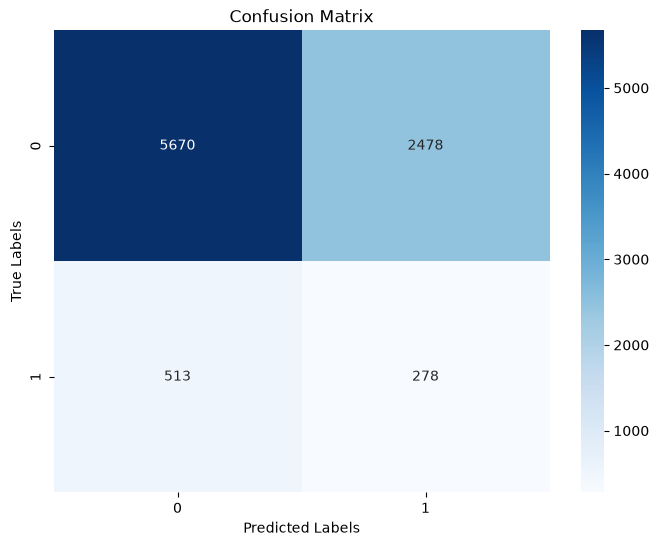

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.70      0.79      8148
           3       0.10      0.35      0.16       791

    accuracy                           0.67      8939
   macro avg       0.51      0.52      0.47      8939
weighted avg       0.84      0.67      0.74      8939



In [ ]:
model = DecisionTreeClassifier(criterion='gini', max_depth=13, max_features='sqrt', min_samples_leaf=1, min_samples_split=9,
                               splitter='best',random_state=42)

model.fit(X2_train_robust, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_standard)

# Evaluate the model
evaluate_model(model,X2_train_robust,y2_test,y_pred)

##  Random Forest

### Standard Scaler

In [ ]:
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X2_train_standard, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_standard)

# Evaluate the model
evaluate_model(model,X2_train_standard,y2_test,y_pred)

### Robust Scaler

Train score: 100.00%

Accuracy: 90.54%



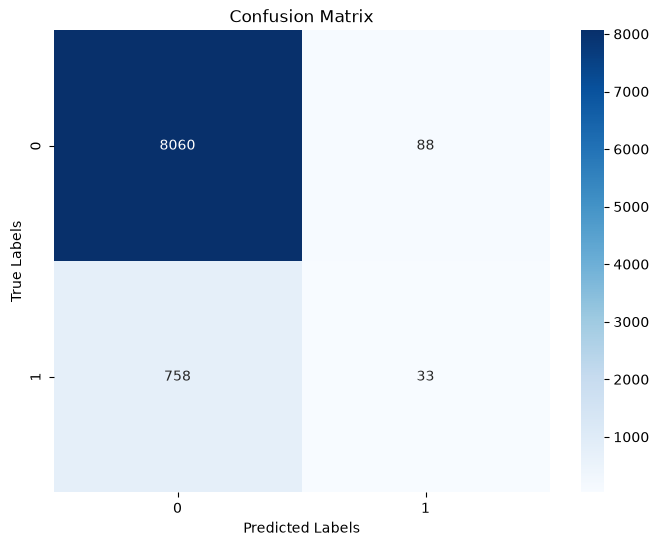

Classification Report:
              precision    recall  f1-score   support

           2       0.91      0.99      0.95      8148
           3       0.27      0.04      0.07       791

    accuracy                           0.91      8939
   macro avg       0.59      0.52      0.51      8939
weighted avg       0.86      0.91      0.87      8939



In [ ]:
model = RandomForestClassifier(bootstrap=True, n_estimators=300, random_state=42, criterion='gini')
model.fit(X2_train_robust, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_robust)

# Evaluate the model
evaluate_model(model,X2_train_robust,y2_test,y_pred)

## Gradient Boosting

Train score: 95.65%

Accuracy: 89.88%



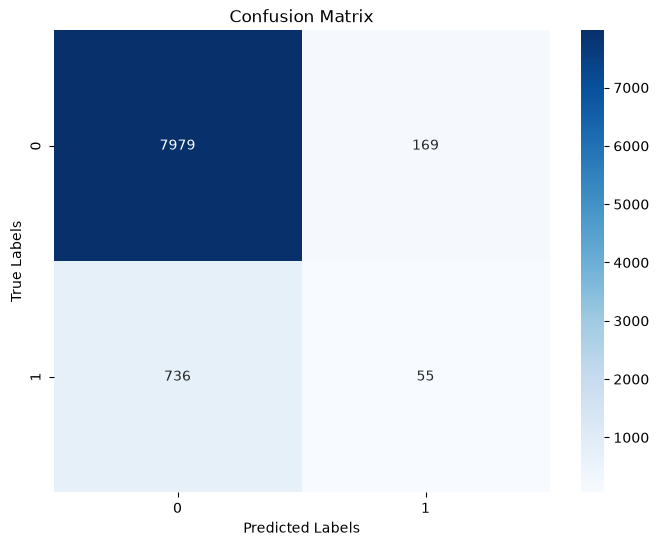

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.98      0.95      8148
           3       0.25      0.07      0.11       791

    accuracy                           0.90      8939
   macro avg       0.58      0.52      0.53      8939
weighted avg       0.86      0.90      0.87      8939



In [ ]:
model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.8, loss='log_loss', random_state=42)

model.fit(X2_train_standard, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_standard)

# Evaluate the model
evaluate_model(model,X2_train_standard,y2_test,y_pred)

## Robust Scaler

Train score: 95.65%

Accuracy: 89.89%



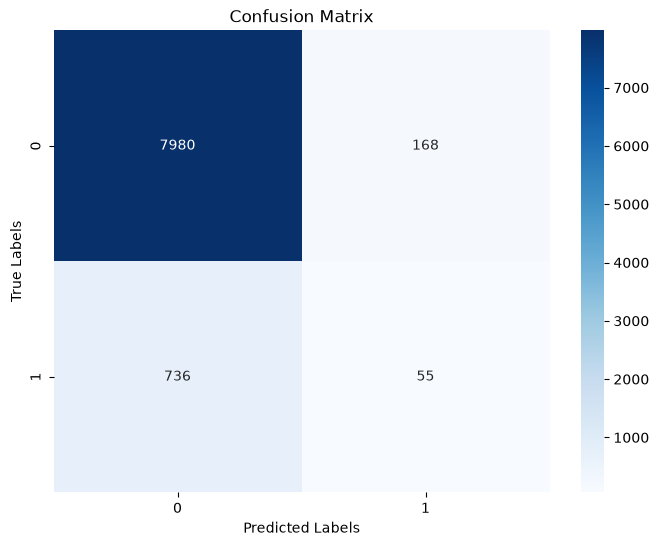

Classification Report:
              precision    recall  f1-score   support

           2       0.92      0.98      0.95      8148
           3       0.25      0.07      0.11       791

    accuracy                           0.90      8939
   macro avg       0.58      0.52      0.53      8939
weighted avg       0.86      0.90      0.87      8939



In [ ]:
model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.8, loss='log_loss', random_state=42)

model.fit(X2_train_robust, y2_train_resampled)

# Make predictions on the test data
y_pred = model.predict(X2_test_robust)

# Evaluate the model
evaluate_model(model,X2_train_robust,y2_test,y_pred)